In [2]:
from pdb import TESTCMD

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



In [6]:
df = pd.read_csv("C:/Users/azilk/Downloads/customer_behavior.csv")

df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 5000
Number of columns: 7

Column names:
['CustomerID', 'Gender', 'Region', 'PurchaseAmount', 'ProductCategory', 'Churn', 'CampaignGroup']

Data types:
CustomerID           int64
Gender                 str
Region                 str
PurchaseAmount     float64
ProductCategory        str
Churn                  str
CampaignGroup          str
dtype: object


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64


In [9]:
df.describe()

,CustomerID,PurchaseAmount
count,5000.000000,4850.000000
mean,3500.500000,1003.950670
std,1443.520003,482.113122
min,1001.000000,0.000000
25%,2250.750000,673.642500
50%,3500.500000,998.080000
75%,4750.250000,1327.077500
max,6000.000000,2688.880000


In [10]:
#1
mean_purchase = df["PurchaseAmount"].mean()
median_purchase = df["PurchaseAmount"].median()
mode_purchase = df["PurchaseAmount"].mode()[0]

print("Mean Purchase Amount:", mean_purchase)
print("Median Purchase Amount:", median_purchase)
print("Mode Purchase Amount:", mode_purchase)

Mean Purchase Amount: 1003.9506701030928
Median Purchase Amount: 998.0799999999999
Mode Purchase Amount: 0.0


In [11]:
#2
Q1 = df["PurchaseAmount"].quantile(0.25)
Q3 = df["PurchaseAmount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["PurchaseAmount"] < lower_bound) |
    (df["PurchaseAmount"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 673.6424999999999
Q3: 1327.0775
IQR: 653.4350000000002
Lower Bound: -306.51000000000033
Upper Bound: 2307.2300000000005
Number of outliers: 15


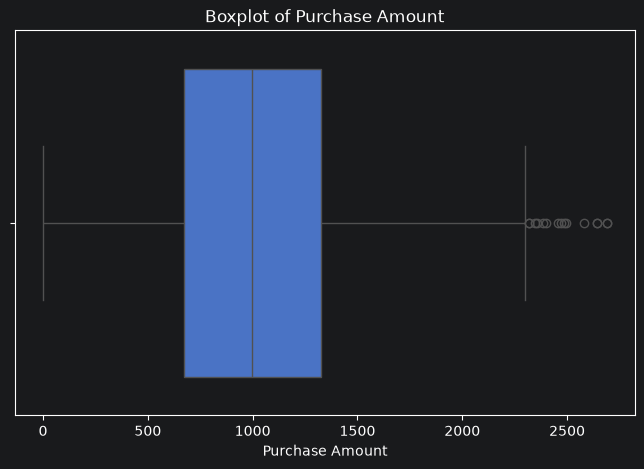

In [12]:
#2BOXPLOT
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["PurchaseAmount"])

plt.title("Boxplot of Purchase Amount")
plt.xlabel("Purchase Amount")

plt.show()

In [13]:
#3
skewness = df["PurchaseAmount"].skew()
kurtosis = df["PurchaseAmount"].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


In [14]:
#4
# INDEPENDENT TWO SAMPLE TEST
gender_summary = df.groupby("Gender")["PurchaseAmount"].agg(
    ["count", "mean", "median", "std"]
)

gender_summary

,count,mean,median,std
Gender,,,,
Female,2370,987.872046,983.000,485.763793
Male,2386,1019.176609,1011.215,480.225125


In [15]:
male_spending = df[df["Gender"] == "Male"]["PurchaseAmount"]
female_spending = df[df["Gender"] == "Female"]["PurchaseAmount"]

In [16]:
t_stat, p_value = stats.ttest_ind(
    male_spending,
    female_spending,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: nan
P-value: nan


In [17]:
#INTERPRETATION
alpha = 0.05

if p_value < alpha:
    print("There is a statistically significant difference in spending between male and female customers.")
else:
    print("There is no statistically significant difference in spending between male and female customers.")

There is no statistically significant difference in spending between male and female customers.


In [18]:
#5 CHI-SQUARE TEST
contingency_table = pd.crosstab(
    df["ProductCategory"],
    df["Churn"]
)

contingency_table

Churn,No,Yes
ProductCategory,,
Electronics,785,541
Fashion,839,607
Grocery,855,604


In [19]:
chi2, p_value, degrees_freedom, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", degrees_freedom)
print("P-value:", p_value)

Chi-square statistic: 0.3960436652673918
Degrees of freedom: 2
P-value: 0.8203519424988512


In [20]:
#INTERPRETATION5
if p_value < 0.05:
    print("There is a statistically significant relationship between ProductCategory and Churn.")
else:
    print("There is no statistically significant relationship between ProductCategory and Churn.")

There is no statistically significant relationship between ProductCategory and Churn.


In [21]:
#6 ONE-WAY ANOVA
region_summary = df.groupby("Region")["PurchaseAmount"].agg(
    ["count", "mean", "median", "std"]
)

region_summary

,count,mean,median,std
Region,,,,
East,1195,1009.946017,1006.290,490.355691
North,1167,1013.017952,1000.160,467.897373
South,1202,997.603877,1000.935,484.095616
West,1115,995.247327,985.160,485.801447


In [22]:
regions = df["Region"].unique()

region_groups = [
    df[df["Region"] == region]["PurchaseAmount"]
    for region in regions
]

f_stat, p_value = stats.f_oneway(*region_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: nan
P-value: nan


In [23]:
#INTERPRETATION
if p_value < 0.05:
    print("There is a statistically significant difference in PurchaseAmount across regions.")
else:
    print("There is no statistically significant difference in PurchaseAmount across regions.")

There is no statistically significant difference in PurchaseAmount across regions.


In [24]:
#7
campaign_summary = df.groupby("CampaignGroup")["PurchaseAmount"].agg(
    ["count", "mean", "median", "std"]
)

campaign_summary

,count,mean,median,std
CampaignGroup,,,,
A,2350,1011.945587,1010.155,480.160915
B,2318,994.339965,977.235,487.383742


In [25]:
campaign_a_mean = df[
    df["CampaignGroup"] == "A"
]["PurchaseAmount"].mean()

campaign_b_mean = df[
    df["CampaignGroup"] == "B"
]["PurchaseAmount"].mean()

print(f"Campaign A average PurchaseAmount: {campaign_a_mean:.2f}")
print(f"Campaign B average PurchaseAmount: {campaign_b_mean:.2f}")

Campaign A average PurchaseAmount: 1011.95
Campaign B average PurchaseAmount: 994.34


In [26]:
if campaign_a_mean > campaign_b_mean:
    print("Campaign A has the higher average PurchaseAmount.")
elif campaign_b_mean > campaign_a_mean:
    print("Campaign B has the higher average PurchaseAmount.")
else:
    print("Both campaigns have the same average PurchaseAmount.")

Campaign A has the higher average PurchaseAmount.


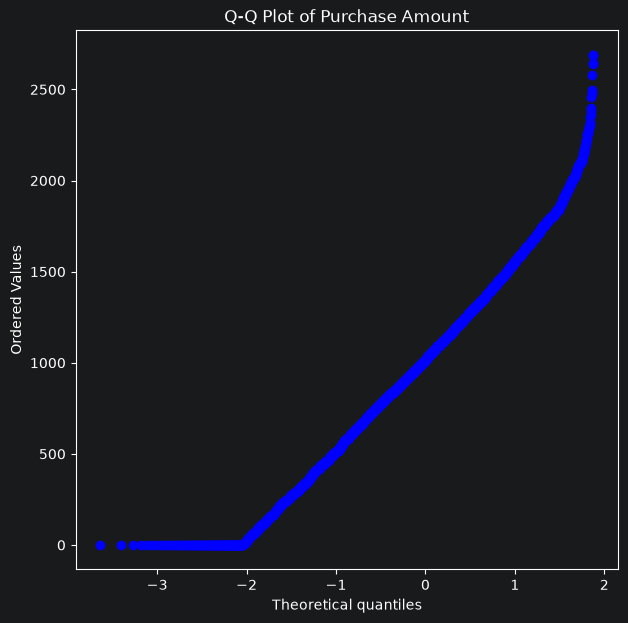

In [27]:
#8 QQ PLOT
plt.figure(figsize=(7, 7))

stats.probplot(
    df["PurchaseAmount"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Purchase Amount")

plt.show()

In [28]:
#SHAPIRO-WILK TEST
sample_data = df["PurchaseAmount"].sample(
    n=min(5000, len(df)),
    random_state=42
)

shapiro_stat, shapiro_p = stats.shapiro(sample_data)

print("Shapiro-Wilk statistic:", shapiro_stat)
print("P-value:", shapiro_p)

Shapiro-Wilk statistic: nan
P-value: nan


In [29]:
if shapiro_p < 0.05:
    print("The Shapiro-Wilk test suggests that PurchaseAmount is not normally distributed.")
else:
    print("The Shapiro-Wilk test does not provide sufficient evidence against normality.")

The Shapiro-Wilk test does not provide sufficient evidence against normality.


In [30]:
#9
population = df["PurchaseAmount"]

sample_size = 30
number_of_samples = 1000

sample_means = []

for i in range(number_of_samples):
    sample = population.sample(
        n=sample_size,
        random_state=i
    )

    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

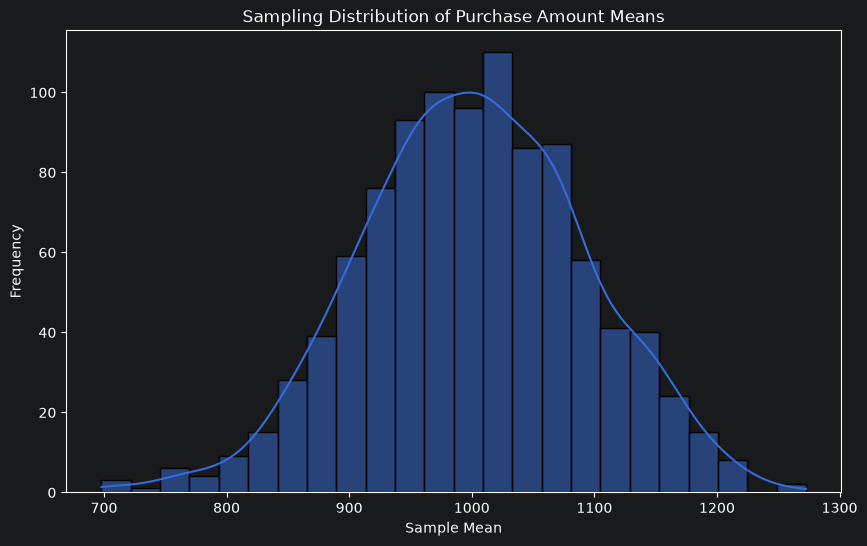

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    sample_means,
    kde=True
)

plt.title("Sampling Distribution of Purchase Amount Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

In [32]:
print("Population mean:", population.mean())
print("Mean of sample means:", sample_means.mean())
print("Standard deviation of sample means:", sample_means.std())

Population mean: 1003.9506701030928
Mean of sample means: 1001.7862817865072
Standard deviation of sample means: 91.39298878730655


In [33]:
print(
    "The Central Limit Theorem shows that the distribution of sample means "
    "tends to become approximately normal as the sample size increases."
)

print(
    "The mean of the sample means should be close to the population mean."
)

The Central Limit Theorem shows that the distribution of sample means tends to become approximately normal as the sample size increases.
The mean of the sample means should be close to the population mean.


In [34]:
#10
data = df["PurchaseAmount"]

n = len(data)
mean = data.mean()
std = data.std(ddof=1)

confidence_level = 0.95
alpha = 1 - confidence_level

standard_error = std / np.sqrt(n)

t_critical = stats.t.ppf(
    1 - alpha / 2,
    df=n - 1
)

margin_of_error = t_critical * standard_error

lower_limit = mean - margin_of_error
upper_limit = mean + margin_of_error

print(f"Sample mean: {mean:.2f}")
print(f"Standard error: {standard_error:.2f}")
print(f"Margin of error: {margin_of_error:.2f}")
print(f"95% Confidence Interval: ({lower_limit:.2f}, {upper_limit:.2f})")

Sample mean: 1003.95
Standard error: 6.82
Margin of error: 13.37
95% Confidence Interval: (990.58, 1017.32)
